# Dataset analysis

## 1. Setup and data loading

In [1]:
print("\n" + "=" * 80)
print("1. SETUP AND DATA LOADING")
print("=" * 80)

import warnings
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: "%.3f" % x)

df = pd.read_json("../generation/dataset/cct_ft_100pct.json")

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


1. SETUP AND DATA LOADING
Shape: 1,296,675 rows × 23 columns
Memory usage: 408.26 MB


## 2. Dataset overview

In [2]:
print("\n" + "=" * 80)
print("2. DATASET OVERVIEW")
print("=" * 80)

print("\n2.1 Column Information")
print("-" * 80)
print(f"\nTotal columns: {len(df.columns)}")
for i, col in enumerate(df.columns, 1):
    print(f"{i:3d}. {col:<30} | Type: {str(df[col].dtype):<10} | Unique: {df[col].nunique():>8,}")


2. DATASET OVERVIEW

2.1 Column Information
--------------------------------------------------------------------------------

Total columns: 23
  1. Unnamed: 0                     | Type: int64      | Unique: 1,296,675
  2. cc_num                         | Type: int64      | Unique:      983
  3. merchant                       | Type: str        | Unique:      693
  4. category                       | Type: str        | Unique:       14
  5. amt                            | Type: float64    | Unique:   52,928
  6. first                          | Type: str        | Unique:      352
  7. last                           | Type: str        | Unique:      481
  8. gender                         | Type: str        | Unique:        2
  9. street                         | Type: str        | Unique:      983
 10. city                           | Type: str        | Unique:      894
 11. state                          | Type: str        | Unique:       51
 12. zip                            | Ty

## 3. Data types and structure

In [3]:
print("\n" + "=" * 80)
print("3. DATA TYPES AND STRUCTURE")
print("=" * 80)

print("\n3.1 Data Type Summary")
print("-" * 80)
dtype_summary = df.dtypes.value_counts().to_frame('Count')
dtype_summary['Percentage'] = (dtype_summary['Count'] / len(df.columns) * 100).round(2)
print(dtype_summary)

print("\n3.2 Detailed Data Types")
print("-" * 80)
df.info()

print("\n3.3 Memory Usage by Column")
print("-" * 80)
memory_usage = df.memory_usage(deep=True).to_frame('Bytes')
memory_usage['MB'] = (memory_usage['Bytes'] / 1024**2).round(3)
memory_usage = memory_usage.sort_values('Bytes', ascending=False).head(10)
print(memory_usage)


3. DATA TYPES AND STRUCTURE

3.1 Data Type Summary
--------------------------------------------------------------------------------
               Count  Percentage
str               12      52.170
int64              5      21.740
float64            5      21.740
datetime64[s]      1       4.350

3.2 Detailed Data Types
--------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column         Non-Null Count    Dtype        
---  ------         --------------    -----        
 0   Unnamed: 0     1296675 non-null  int64        
 1   cc_num         1296675 non-null  int64        
 2   merchant       1296675 non-null  str          
 3   category       1296675 non-null  str          
 4   amt            1296675 non-null  float64      
 5   first          1296675 non-null  str          
 6   last           1296675 non-null  str          
 7   gender         129667

## 4. Data quality assessment

In [4]:
print("\n" + "=" * 80)
print("4. DATA QUALITY ASSESSMENT")
print("=" * 80)

print("\n4.1 Missing Values Analysis")
print("-" * 80)
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2),
    'Data_Type': df.dtypes
})
missing_data = missing_data.sort_values('Missing_Percentage', ascending=False)
print(missing_data)

total_missing = df.isnull().sum().sum()
print(f"\nTotal missing values: {total_missing:,} ({total_missing / (len(df) * len(df.columns)) * 100:.2f}% of all values)")

print("\n4.2 Duplicate Records")
print("-" * 80)
duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates:,} ({duplicates / len(df) * 100:.2f}%)")

if duplicates > 0:
    duplicate_subset = df.duplicated(subset=None, keep=False).sum()
    print(f"Rows involved in duplicates: {duplicate_subset:,}")


4. DATA QUALITY ASSESSMENT

4.1 Missing Values Analysis
--------------------------------------------------------------------------------
                      Column  Missing_Count  Missing_Percentage      Data_Type
Unnamed: 0        Unnamed: 0              0               0.000          int64
cc_num                cc_num              0               0.000          int64
merchant            merchant              0               0.000            str
category            category              0               0.000            str
amt                      amt              0               0.000        float64
first                  first              0               0.000            str
last                    last              0               0.000            str
gender                gender              0               0.000            str
street                street              0               0.000            str
city                    city              0               0.000         

## 5. Numerical features analysis


5. NUMERICAL FEATURES ANALYSIS

Found 10 numerical columns

5.1 Statistical Summary
--------------------------------------------------------------------------------
       Unnamed: 0                  cc_num         amt         zip         lat  \
count 1296675.000             1296675.000 1296675.000 1296675.000 1296675.000   
mean   648337.000  417192042079726656.000      70.351   48800.671      38.538   
std    374317.974 1308806447000240384.000     160.316   26893.222       5.076   
min         0.000         60416207185.000       1.000    1257.000      20.027   
25%    324168.500     180042946491150.000       9.650   26237.000      34.620   
50%    648337.000    3521417320836166.000      47.520   48174.000      39.354   
75%    972505.500    4642255475285942.000      83.140   72042.000      41.940   
max   1296674.000 4992346398065154048.000   28948.900   99783.000      66.693   

             long    city_pop   merch_lat  merch_long    is_fraud  
count 1296675.000 1296675.000 129667

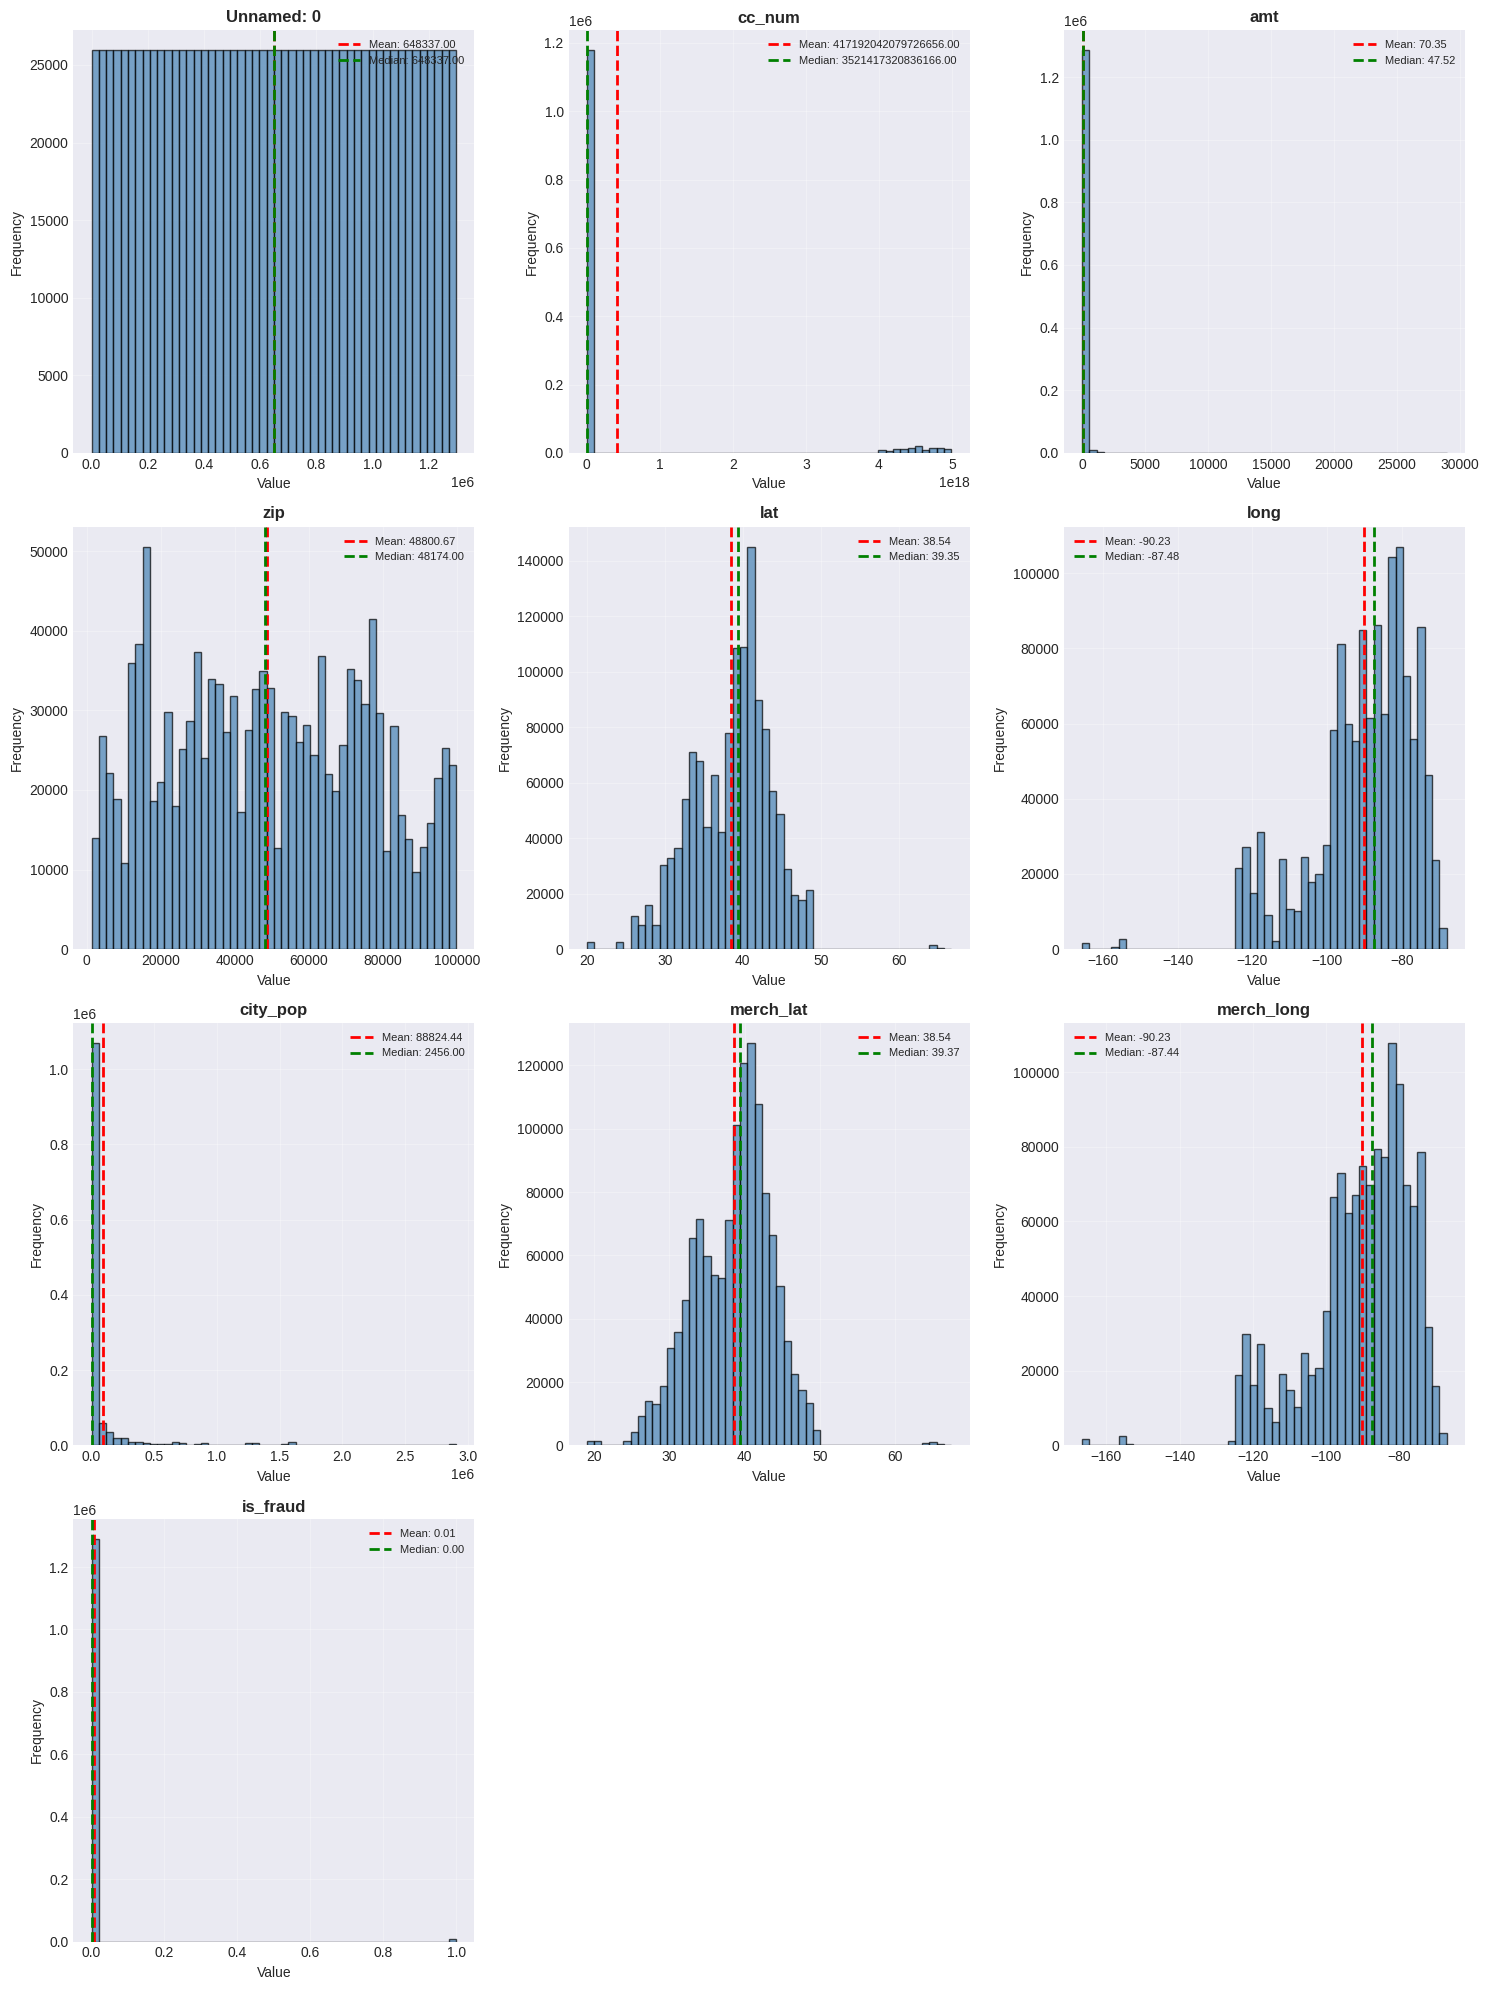


5.4 Outlier Detection
--------------------------------------------------------------------------------
       Column  Outlier_Count  Outlier_Percentage           Lower_Bound  \
6    city_pop         242674              18.720            -28634.500   
1      cc_num         118789               9.160 -6513275846701038.000   
2         amt          67290               5.190              -100.585   
5        long          49922               3.850              -121.758   
8  merch_long          41994               3.240              -121.888   
9    is_fraud           7506               0.580                 0.000   
7   merch_lat           4967               0.380                23.898   
4         lat           4679               0.360                23.641   
0  Unnamed: 0              0               0.000           -648337.000   
3         zip              0               0.000            -42470.500   

            Upper_Bound  
6             49705.500  
1 11335574268478130.000  
2  

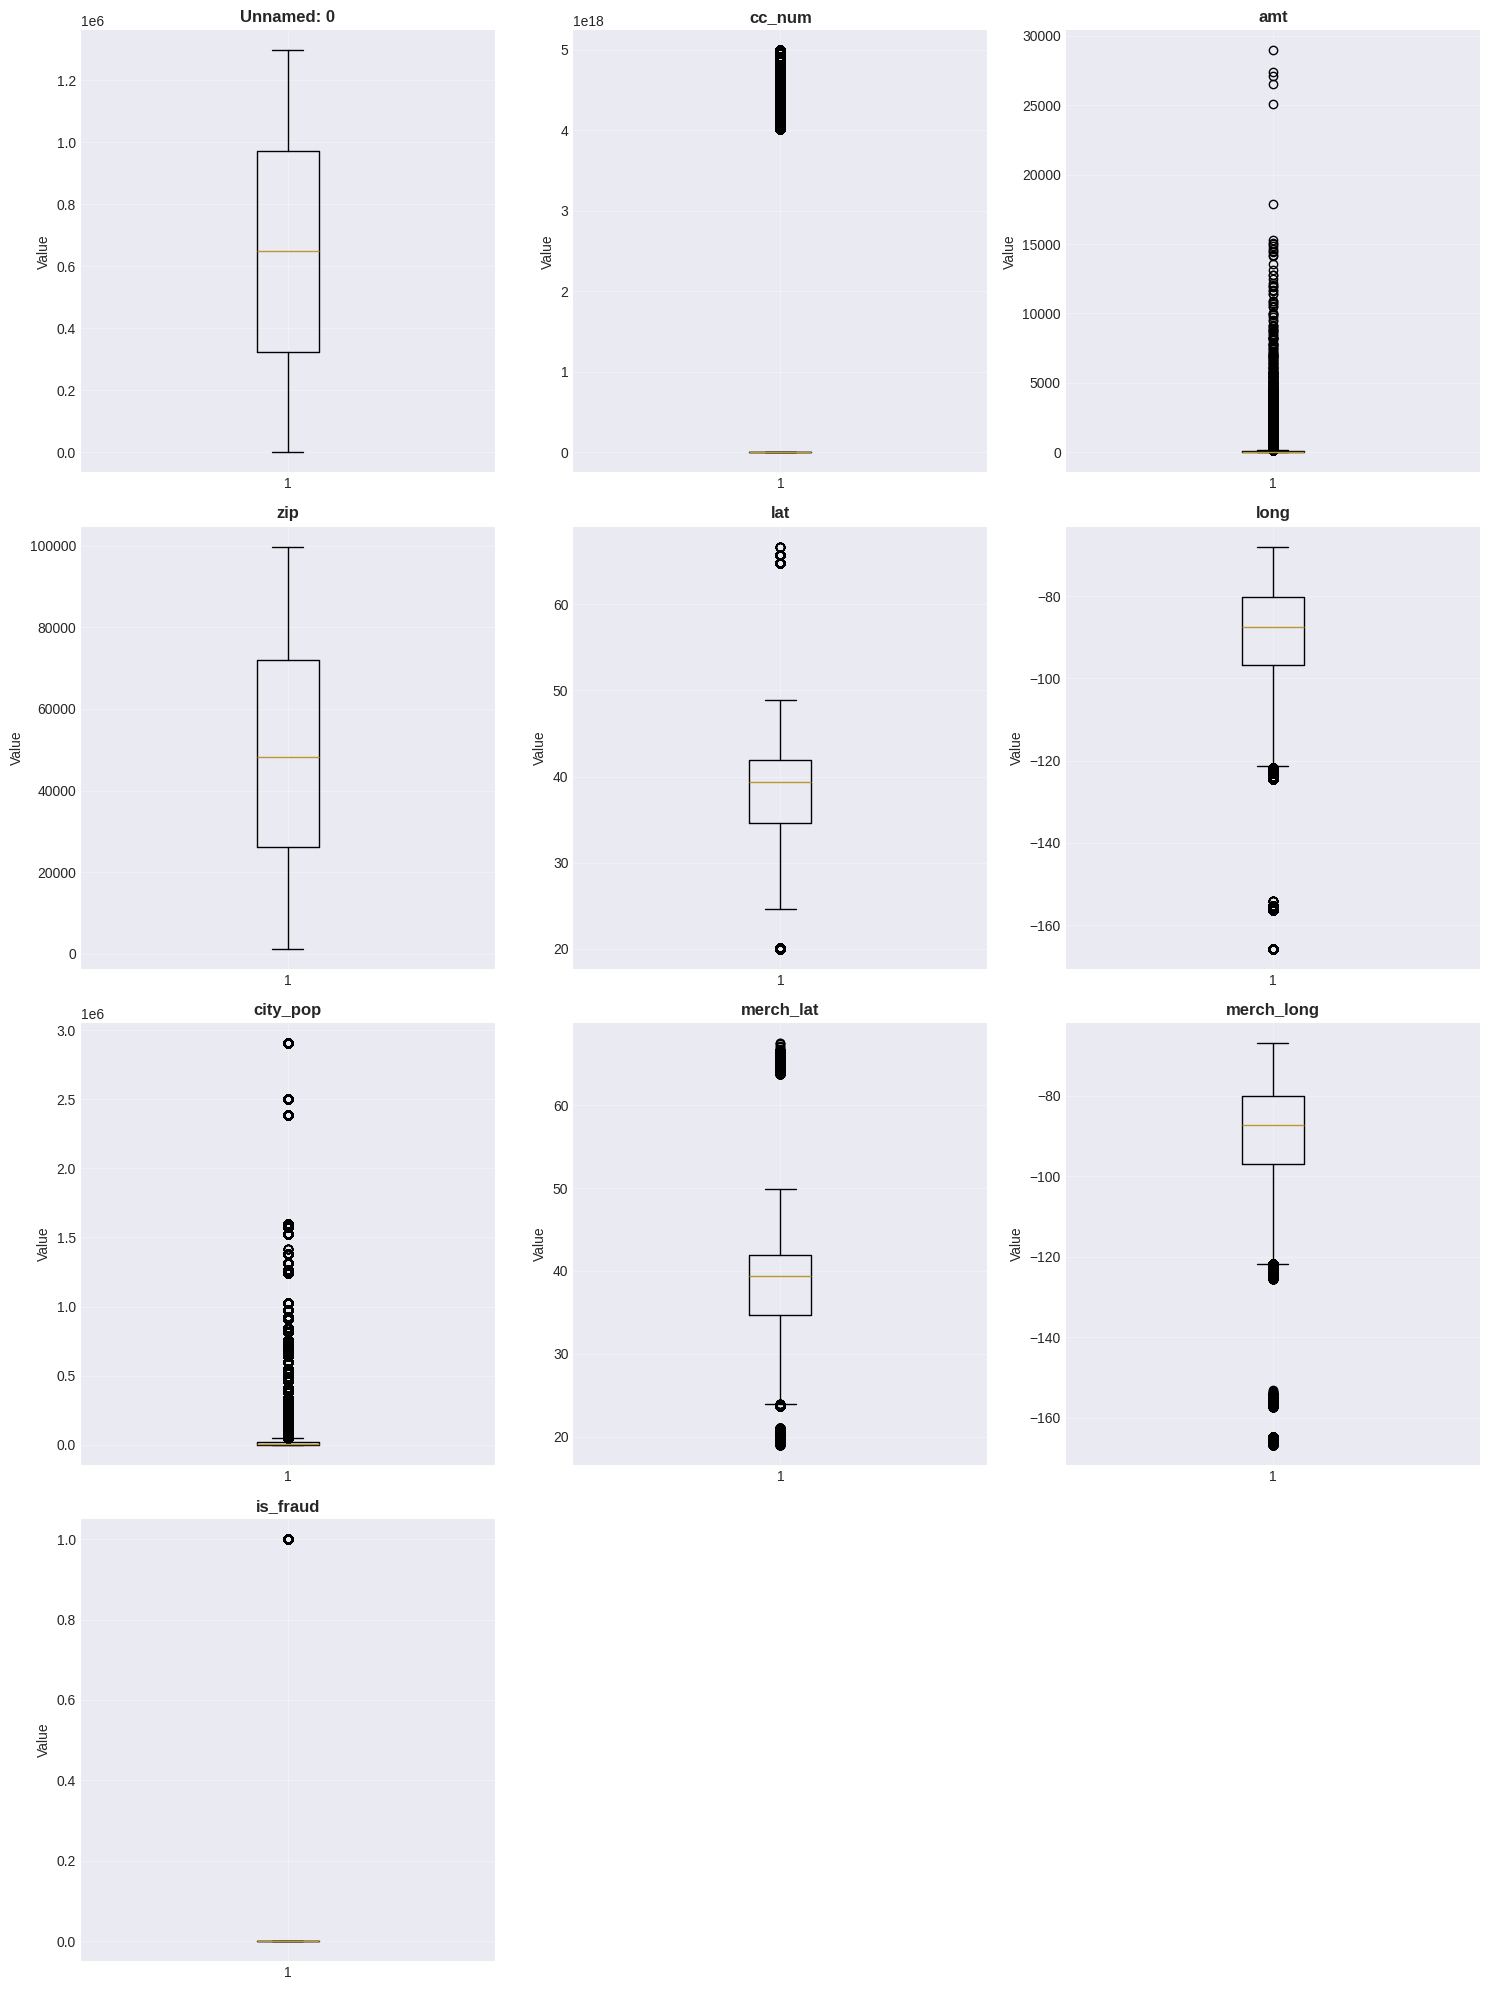

In [5]:
print("\n" + "=" * 80)
print("5. NUMERICAL FEATURES ANALYSIS")
print("=" * 80)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nFound {len(numerical_cols)} numerical columns")

print("\n5.1 Statistical Summary")
print("-" * 80)
print(df[numerical_cols].describe())

print("\n5.2 Extended Statistics")
print("-" * 80)
extended_stats = pd.DataFrame({
    'Column': numerical_cols,
    'Mean': [df[col].mean() for col in numerical_cols],
    'Median': [df[col].median() for col in numerical_cols],
    'Std': [df[col].std() for col in numerical_cols],
    'Skewness': [df[col].skew() for col in numerical_cols],
    'Kurtosis': [df[col].kurtosis() for col in numerical_cols],
    'CV': [df[col].std() / df[col].mean() if df[col].mean() != 0 else 0 for col in numerical_cols]
})
extended_stats = extended_stats.round(3)
print(extended_stats)

print("\n5.3 Distribution Analysis")
print("-" * 80)

n_cols_to_plot = min(len(numerical_cols), 12)
if n_cols_to_plot > 0:
    n_rows = (n_cols_to_plot + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_cols_to_plot > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols[:n_cols_to_plot]):
        axes[idx].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{col}', fontweight='bold')
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(alpha=0.3)
        
        mean_val = df[col].mean()
        median_val = df[col].median()
        axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.2f}')
        axes[idx].legend(fontsize=8)
    
    for idx in range(n_cols_to_plot, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

print("\n5.4 Outlier Detection")
print("-" * 80)

outlier_summary = []
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df) * 100)
    
    outlier_summary.append({
        'Column': col,
        'Outlier_Count': outlier_count,
        'Outlier_Percentage': round(outlier_percentage, 2),
        'Lower_Bound': round(lower_bound, 3),
        'Upper_Bound': round(upper_bound, 3)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('Outlier_Percentage', ascending=False)
print(outlier_df)

n_cols_to_plot = min(len(numerical_cols), 12)
if n_cols_to_plot > 0:
    n_rows = (n_cols_to_plot + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_cols_to_plot > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols[:n_cols_to_plot]):
        axes[idx].boxplot(df[col].dropna(), vert=True)
        axes[idx].set_title(f'{col}', fontweight='bold')
        axes[idx].set_ylabel('Value')
        axes[idx].grid(alpha=0.3)
    
    for idx in range(n_cols_to_plot, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

## 6. Categorical features analysis


6. CATEGORICAL FEATURES ANALYSIS

Found 12 categorical columns

6.1 Categorical Features Summary
--------------------------------------------------------------------------------
           Column  Unique_Values                       Most_Common  \
10      trans_num        1296675  00000ecad06b03d3a8d34b4e30b5ce3b   
11  merch_zipcode          28337                                     
5          street            983        0069 Robin Brooks Apt. 695   
9             dob            968                        1977-03-23   
6            city            894                        Birmingham   
0        merchant            693                 fraud_Kilback LLC   
8             job            494                 Film/video editor   
3            last            481                             Smith   
2           first            352                       Christopher   
7           state             51                                TX   
1        category             14                   

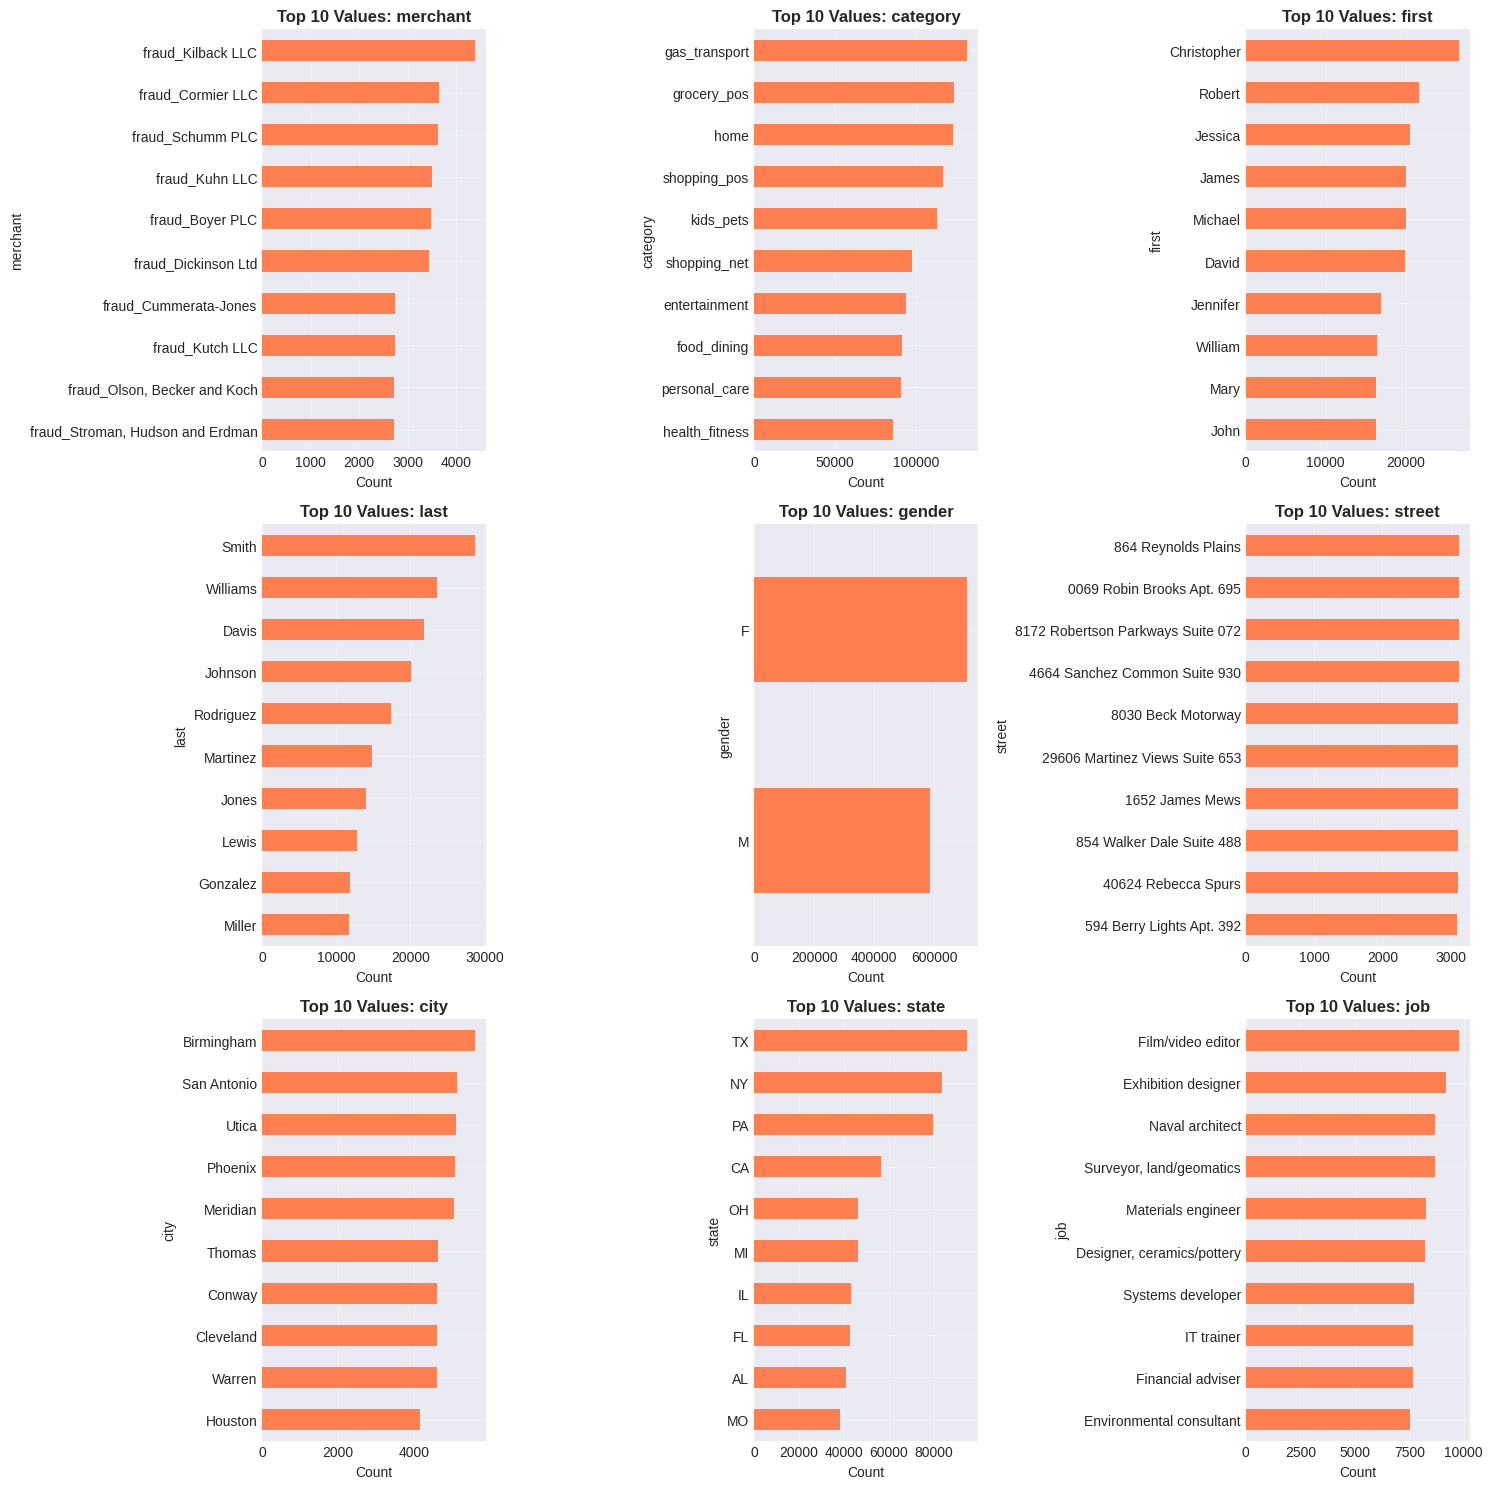

In [6]:
print("\n" + "=" * 80)
print("6. CATEGORICAL FEATURES ANALYSIS")
print("=" * 80)

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nFound {len(categorical_cols)} categorical columns")

print("\n6.1 Categorical Features Summary")
print("-" * 80)
cat_summary = []
for col in categorical_cols:
    cat_summary.append({
        'Column': col,
        'Unique_Values': df[col].nunique(),
        'Most_Common': df[col].mode()[0] if len(df[col].mode()) > 0 else None,
        'Most_Common_Freq': df[col].value_counts().iloc[0] if len(df[col]) > 0 else 0,
        'Most_Common_Pct': round(df[col].value_counts(normalize=True).iloc[0] * 100, 2) if len(df[col]) > 0 else 0
    })
cat_summary_df = pd.DataFrame(cat_summary).sort_values('Unique_Values', ascending=False)
print(cat_summary_df)

print("\n6.2 Value Counts for Each Categorical Feature")
print("-" * 80)
for col in categorical_cols[:10]:
    print(f"\n{col}:")
    value_counts = df[col].value_counts().head(15)
    value_pcts = df[col].value_counts(normalize=True).head(15) * 100
    
    combined = pd.DataFrame({
        'Count': value_counts,
        'Percentage': value_pcts.round(2)
    })
    print(combined)

n_cols_to_plot = min(len(categorical_cols), 9)
if n_cols_to_plot > 0:
    n_rows = (n_cols_to_plot + 2) // 3
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_cols_to_plot > 1 else [axes]
    
    for idx, col in enumerate(categorical_cols[:n_cols_to_plot]):
        top_values = df[col].value_counts().head(10)
        top_values.plot(kind='barh', ax=axes[idx], color='coral')
        axes[idx].set_title(f'Top 10 Values: {col}', fontweight='bold')
        axes[idx].set_xlabel('Count')
        axes[idx].invert_yaxis()
        axes[idx].grid(alpha=0.3)
    
    for idx in range(n_cols_to_plot, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

## 7. Correlation analysis


7. CORRELATION ANALYSIS

7.1 Correlation Matrix
--------------------------------------------------------------------------------
            Unnamed: 0  cc_num    amt    zip    lat   long  city_pop  \
Unnamed: 0       1.000   0.000 -0.000  0.001  0.001 -0.001    -0.002   
cc_num           0.000   1.000  0.002  0.041 -0.059 -0.048    -0.009   
amt             -0.000   0.002  1.000  0.002 -0.002 -0.000     0.006   
zip              0.001   0.041  0.002  1.000 -0.114 -0.910     0.078   
lat              0.001  -0.059 -0.002 -0.114  1.000 -0.016    -0.156   
long            -0.001  -0.048 -0.000 -0.910 -0.016  1.000    -0.053   
city_pop        -0.002  -0.009  0.006  0.078 -0.156 -0.053     1.000   
merch_lat        0.001  -0.059 -0.002 -0.114  0.994 -0.015    -0.155   
merch_long      -0.001  -0.048 -0.000 -0.909 -0.016  0.999    -0.053   
is_fraud        -0.005  -0.001  0.219 -0.002  0.002  0.002     0.002   

            merch_lat  merch_long  is_fraud  
Unnamed: 0      0.001      -0.0

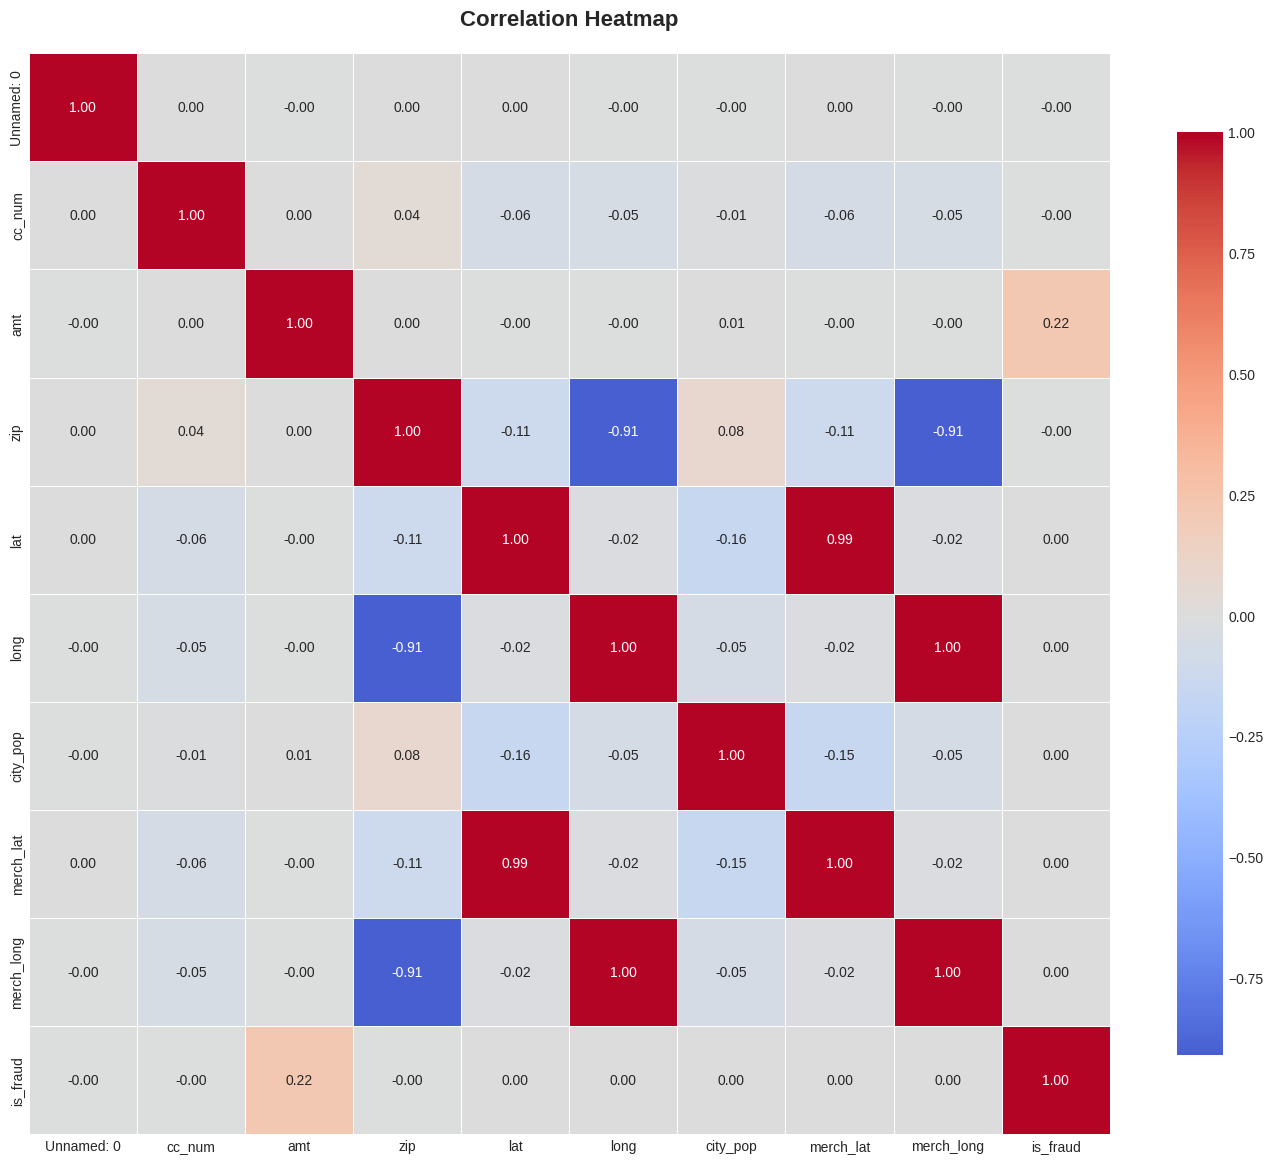


7.2 Highly Correlated Feature Pairs
--------------------------------------------------------------------------------

Strong correlations (|r| > 0.7):
   Feature_1   Feature_2  Correlation
37      long  merch_long        0.999
32       lat   merch_lat        0.994
25       zip        long       -0.910
28       zip  merch_long       -0.909


In [7]:
print("\n" + "=" * 80)
print("7. CORRELATION ANALYSIS")
print("=" * 80)

if len(numerical_cols) > 1:
    print("\n7.1 Correlation Matrix")
    print("-" * 80)
    
    correlation_matrix = df[numerical_cols].corr()
    print(correlation_matrix)
    
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        ax=ax,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )
    ax.set_title("Correlation Heatmap", fontsize=16, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.show()
    
    print("\n7.2 Highly Correlated Feature Pairs")
    print("-" * 80)
    
    corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i + 1, len(correlation_matrix.columns)):
            corr_pairs.append({
                'Feature_1': correlation_matrix.columns[i],
                'Feature_2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })
    
    corr_df = pd.DataFrame(corr_pairs)
    corr_df['Abs_Correlation'] = corr_df['Correlation'].abs()
    corr_df = corr_df.sort_values('Abs_Correlation', ascending=False)
    
    high_corr = corr_df[corr_df['Abs_Correlation'] > 0.7].head(20)
    if len(high_corr) > 0:
        print("\nStrong correlations (|r| > 0.7):")
        print(high_corr[['Feature_1', 'Feature_2', 'Correlation']])
    else:
        print("\nNo strong correlations found (threshold: |r| > 0.7)")

## 8. Data distribution tests

In [8]:
print("\n" + "=" * 80)
print("8. DATA DISTRIBUTION TESTS")
print("=" * 80)

print("\n8.1 Normality Tests (Shapiro-Wilk)")
print("-" * 80)

normality_results = []
for col in numerical_cols[:20]:
    sample_size = min(5000, len(df[col].dropna()))
    sample_data = df[col].dropna().sample(n=sample_size, random_state=42)
    
    if len(sample_data) >= 3:
        statistic, p_value = stats.shapiro(sample_data)
        is_normal = p_value > 0.05
        
        normality_results.append({
            'Column': col,
            'Statistic': round(statistic, 4),
            'P_Value': round(p_value, 6),
            'Is_Normal': 'Yes' if is_normal else 'No'
        })

normality_df = pd.DataFrame(normality_results)
print(normality_df)
print("\nNote: P-value > 0.05 suggests normal distribution")


8. DATA DISTRIBUTION TESTS

8.1 Normality Tests (Shapiro-Wilk)
--------------------------------------------------------------------------------
       Column  Statistic  P_Value Is_Normal
0  Unnamed: 0      0.954    0.000        No
1      cc_num      0.330    0.000        No
2         amt      0.364    0.000        No
3         zip      0.964    0.000        No
4         lat      0.981    0.000        No
5        long      0.920    0.000        No
6    city_pop      0.291    0.000        No
7   merch_lat      0.983    0.000        No
8  merch_long      0.921    0.000        No
9    is_fraud      0.050    0.000        No

Note: P-value > 0.05 suggests normal distribution


## 9. Summary

In [9]:
print("\n" + "=" * 80)
print("9. SUMMARY")
print("=" * 80)

print("\n9.1 Dataset Characteristics")
print("-" * 80)
print(f"Total Rows: {len(df):,}")
print(f"Total Columns: {len(df.columns)}")
print(f"Numerical Columns: {len(numerical_cols)}")
print(f"Categorical Columns: {len(categorical_cols)}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n9.2 Data Quality Metrics")
print("-" * 80)
print(f"Total Missing Values: {df.isnull().sum().sum():,} ({df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100:.2f}%)")
print(f"Columns with Missing Values: {(df.isnull().sum() > 0).sum()}")
print(f"Duplicate Rows: {duplicates:,} ({duplicates / len(df) * 100:.2f}%)")

print("\n9.3 Feature Characteristics")
print("-" * 80)
if len(numerical_cols) > 0:
    print(f"Numerical Features Range: {df[numerical_cols].min().min():.3f} to {df[numerical_cols].max().max():.3f}")
    print(f"Average Skewness: {extended_stats['Skewness'].mean():.3f}")
    print(f"Average Kurtosis: {extended_stats['Kurtosis'].mean():.3f}")

if len(categorical_cols) > 0:
    print(f"Average Unique Categories: {cat_summary_df['Unique_Values'].mean():.0f}")
    print(f"Max Unique Categories: {cat_summary_df['Unique_Values'].max()}")

print("\n9.4 Correlation Insights")
print("-" * 80)
if len(numerical_cols) > 1:
    print(f"Strong Correlations (|r| > 0.7): {len(corr_df[corr_df['Abs_Correlation'] > 0.7])}")
    print(f"Moderate Correlations (0.5 < |r| < 0.7): {len(corr_df[(corr_df['Abs_Correlation'] > 0.5) & (corr_df['Abs_Correlation'] <= 0.7)])}")
    print(f"Weak Correlations (|r| < 0.3): {len(corr_df[corr_df['Abs_Correlation'] < 0.3])}")


9. SUMMARY

9.1 Dataset Characteristics
--------------------------------------------------------------------------------
Total Rows: 1,296,675
Total Columns: 23
Numerical Columns: 10
Categorical Columns: 12
Memory Usage: 408.26 MB

9.2 Data Quality Metrics
--------------------------------------------------------------------------------
Total Missing Values: 0 (0.00%)
Columns with Missing Values: 0
Duplicate Rows: 0 (0.00%)

9.3 Feature Characteristics
--------------------------------------------------------------------------------
Numerical Features Range: -166.671 to 4992346398065154048.000
Average Skewness: 6.117
Average Kurtosis: 476.022
Average Unique Categories: 110829
Max Unique Categories: 1296675

9.4 Correlation Insights
--------------------------------------------------------------------------------
Strong Correlations (|r| > 0.7): 4
Moderate Correlations (0.5 < |r| < 0.7): 0
Weak Correlations (|r| < 0.3): 41
